# TP 4 — Analyse Factorielle des Correspondances (AFC)


---
**Binôme :** Sellami Mohamed Amine et Abdesselam Meriem — G3 

## Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Paramètres d'affichage
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
pd.set_option('display.max_columns', 15)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

## Données — Tableau de contingence K

In [ ]:
infections = [
    'Angine', 'Pharyngite', 'Asthme', 'Bronchite',
    'Bronchite accr', 'Bronchite chro', 'Inf. gorge',
    'Inf. resp', 'Inf. poumons', 'Sinusite', 'Sinusite chro'
]

antibiotiques = ['AMOX', 'AUGM', 'CEFT', 'CEFX', 'CLAV',
                 'KLAC', 'MAC', 'PAN', 'VECL', 'ZINN']

K_data = np.array([
    [638, 311, 116, 168, 138, 221, 188, 169, 202,  83],
    [489, 495, 142, 136, 200, 230, 167, 217, 141, 104],
    [ 38,  57,  30,  29,  19,  81,  48,  27,  34,   9],
    [170, 188,  98, 150,  95, 150, 136, 120, 140,  35],
    [103, 234, 116, 135,  93, 157,  80,  67,  70,  51],
    [  0,  23,  30,  33,   9,  23,  20,   8,  21,   8],
    [134,  96,  43,  75,  43,  50,  63,  35,  53,  34],
    [264, 265,  58, 117, 101, 140, 143, 124, 119,  80],
    [ 17,  34,  10,   0,  10,  51,  35,   5,  31,   4],
    [ 18,  39,  12,  13,  16,  23,   9,  14,   0,   7],
    [  0,  41,   8,  11,  10,  11,   7,   8,   5,   6]
], dtype=float)

K = pd.DataFrame(K_data, index=infections, columns=antibiotiques)

K['Total_lignes'] = K.sum(axis=1)
K.loc['Total_colonnes'] = K.sum(axis=0)

print("="*70)
print("TABLEAU DE CONTINGENCE K")
print("="*70)
print(K.to_string())
print(f"\n  n (nombre total d'individus) = {int(K.loc['Total_colonnes','Total_lignes'])}")

TABLEAU DE CONTINGENCE K
                    AMOX      AUGM     CEFT     CEFX     CLAV      KLAC      MAC      PAN     VECL     ZINN  Total_lignes
Angine          638.0000  311.0000 116.0000 168.0000 138.0000  221.0000 188.0000 169.0000 202.0000  83.0000     2234.0000
Pharyngite      489.0000  495.0000 142.0000 136.0000 200.0000  230.0000 167.0000 217.0000 141.0000 104.0000     2321.0000
Asthme           38.0000   57.0000  30.0000  29.0000  19.0000   81.0000  48.0000  27.0000  34.0000   9.0000      372.0000
Bronchite       170.0000  188.0000  98.0000 150.0000  95.0000  150.0000 136.0000 120.0000 140.0000  35.0000     1282.0000
Bronchite accr  103.0000  234.0000 116.0000 135.0000  93.0000  157.0000  80.0000  67.0000  70.0000  51.0000     1106.0000
Bronchite chro    0.0000   23.0000  30.0000  33.0000   9.0000   23.0000  20.0000   8.0000  21.0000   8.0000      175.0000
Inf. gorge      134.0000   96.0000  43.0000  75.0000  43.0000   50.0000  63.0000  35.0000  53.0000  34.0000      626.0000

---
## Partie 1 — Matrices des profils lignes et colonnes

In [ ]:
K_mat = K_data.copy()   
n = K_mat.sum()         
p, q = K_mat.shape

print(f"Dimensions : p = {p} infections (lignes), q = {q} antibiotiques (colonnes)")
print(f"n = {int(n)} individus au total")

Dimensions : p = 11 infections (lignes), q = 10 antibiotiques (colonnes)
n = 9982 individus au total


In [ ]:
F_mat = K_mat / n

fi_plus = F_mat.sum(axis=1)   # poids des lignes  (shape p)
f_plus_j = F_mat.sum(axis=0)  # poids des colonnes (shape q)

# Affichage
F_df = pd.DataFrame(F_mat, index=infections, columns=antibiotiques)
F_df['f_i+'] = fi_plus
F_df.loc['f_+j'] = np.append(f_plus_j, fi_plus.sum())

print("="*70)
print("MATRICE DES FRÉQUENCES RELATIVES F = K / n")
print("="*70)
print(F_df.to_string())

print("\nVérification : somme de toutes les fréquences =", round(F_mat.sum(), 6))
print("Vérification : somme f_i+ =", round(fi_plus.sum(), 6))
print("Vérification : somme f_+j =", round(f_plus_j.sum(), 6))

MATRICE DES FRÉQUENCES RELATIVES F = K / n
                 AMOX   AUGM   CEFT   CEFX   CLAV   KLAC    MAC    PAN   VECL   ZINN   f_i+
Angine         0.0639 0.0312 0.0116 0.0168 0.0138 0.0221 0.0188 0.0169 0.0202 0.0083 0.2238
Pharyngite     0.0490 0.0496 0.0142 0.0136 0.0200 0.0230 0.0167 0.0217 0.0141 0.0104 0.2325
Asthme         0.0038 0.0057 0.0030 0.0029 0.0019 0.0081 0.0048 0.0027 0.0034 0.0009 0.0373
Bronchite      0.0170 0.0188 0.0098 0.0150 0.0095 0.0150 0.0136 0.0120 0.0140 0.0035 0.1284
Bronchite accr 0.0103 0.0234 0.0116 0.0135 0.0093 0.0157 0.0080 0.0067 0.0070 0.0051 0.1108
Bronchite chro 0.0000 0.0023 0.0030 0.0033 0.0009 0.0023 0.0020 0.0008 0.0021 0.0008 0.0175
Inf. gorge     0.0134 0.0096 0.0043 0.0075 0.0043 0.0050 0.0063 0.0035 0.0053 0.0034 0.0627
Inf. resp      0.0264 0.0265 0.0058 0.0117 0.0101 0.0140 0.0143 0.0124 0.0119 0.0080 0.1414
Inf. poumons   0.0017 0.0034 0.0010 0.0000 0.0010 0.0051 0.0035 0.0005 0.0031 0.0004 0.0197
Sinusite       0.0018 0.0039 0.0012 0

In [ ]:
XL_mat = F_mat / fi_plus[:, np.newaxis]  

XL_df = pd.DataFrame(XL_mat, index=infections, columns=antibiotiques)
XL_df['f_i+  (poids)'] = fi_plus

print("="*70)
print("MATRICE DES PROFILS-LIGNES XL  [ (XL)_ij = f_ij / f_i+ ]")
print("="*70)
print(XL_df.to_string())
print("\nVérification : somme de chaque ligne (doit être 1) :")
print(np.round(XL_mat.sum(axis=1), 6))

MATRICE DES PROFILS-LIGNES XL  [ (XL)_ij = f_ij / f_i+ ]
                 AMOX   AUGM   CEFT   CEFX   CLAV   KLAC    MAC    PAN   VECL   ZINN  f_i+  (poids)
Angine         0.2856 0.1392 0.0519 0.0752 0.0618 0.0989 0.0842 0.0756 0.0904 0.0372         0.2238
Pharyngite     0.2107 0.2133 0.0612 0.0586 0.0862 0.0991 0.0720 0.0935 0.0607 0.0448         0.2325
Asthme         0.1022 0.1532 0.0806 0.0780 0.0511 0.2177 0.1290 0.0726 0.0914 0.0242         0.0373
Bronchite      0.1326 0.1466 0.0764 0.1170 0.0741 0.1170 0.1061 0.0936 0.1092 0.0273         0.1284
Bronchite accr 0.0931 0.2116 0.1049 0.1221 0.0841 0.1420 0.0723 0.0606 0.0633 0.0461         0.1108
Bronchite chro 0.0000 0.1314 0.1714 0.1886 0.0514 0.1314 0.1143 0.0457 0.1200 0.0457         0.0175
Inf. gorge     0.2141 0.1534 0.0687 0.1198 0.0687 0.0799 0.1006 0.0559 0.0847 0.0543         0.0627
Inf. resp      0.1871 0.1878 0.0411 0.0829 0.0716 0.0992 0.1013 0.0879 0.0843 0.0567         0.1414
Inf. poumons   0.0863 0.1726 0.0508 0.0000 

In [ ]:
XC_mat = F_mat / f_plus_j[np.newaxis, :]  

XC_df = pd.DataFrame(XC_mat, index=infections, columns=antibiotiques)
row_poids = pd.DataFrame([f_plus_j], index=['f_+j (poids)'], columns=antibiotiques)
XC_display = pd.concat([XC_df, row_poids])

print("="*70)
print("MATRICE DES PROFILS-COLONNES XC  [ (XC)_ij = f_ij / f_+j ]")
print("="*70)
print(XC_display.to_string())
print("\nVérification : somme de chaque colonne (doit être 1) :")
print(np.round(XC_mat.sum(axis=0), 6))

MATRICE DES PROFILS-COLONNES XC  [ (XC)_ij = f_ij / f_+j ]
                 AMOX   AUGM   CEFT   CEFX   CLAV   KLAC    MAC    PAN   VECL   ZINN
Angine         0.3410 0.1744 0.1750 0.1938 0.1880 0.1944 0.2098 0.2128 0.2475 0.1971
Pharyngite     0.2614 0.2776 0.2142 0.1569 0.2725 0.2023 0.1864 0.2733 0.1728 0.2470
Asthme         0.0203 0.0320 0.0452 0.0334 0.0259 0.0712 0.0536 0.0340 0.0417 0.0214
Bronchite      0.0909 0.1054 0.1478 0.1730 0.1294 0.1319 0.1518 0.1511 0.1716 0.0831
Bronchite accr 0.0551 0.1312 0.1750 0.1557 0.1267 0.1381 0.0893 0.0844 0.0858 0.1211
Bronchite chro 0.0000 0.0129 0.0452 0.0381 0.0123 0.0202 0.0223 0.0101 0.0257 0.0190
Inf. gorge     0.0716 0.0538 0.0649 0.0865 0.0586 0.0440 0.0703 0.0441 0.0650 0.0808
Inf. resp      0.1411 0.1486 0.0875 0.1349 0.1376 0.1231 0.1596 0.1562 0.1458 0.1900
Inf. poumons   0.0091 0.0191 0.0151 0.0000 0.0136 0.0449 0.0391 0.0063 0.0380 0.0095
Sinusite       0.0096 0.0219 0.0181 0.0150 0.0218 0.0202 0.0100 0.0176 0.0000 0.0166
Sinusi

---
## Partie 2 — Étude du nuage des profils-lignes

In [ ]:
gI = np.sqrt(f_plus_j)

print("="*60)
print("CENTRE DE GRAVITÉ DU NUAGE DES PROFILS-LIGNES TRANSFORMÉ")
print("="*60)
gI_df = pd.DataFrame([gI], index=['gI = sqrt(f_+j)'], columns=antibiotiques)
print(gI_df.to_string())

CENTRE DE GRAVITÉ DU NUAGE DES PROFILS-LIGNES TRANSFORMÉ
                  AMOX   AUGM   CEFT   CEFX   CLAV   KLAC    MAC    PAN   VECL   ZINN
gI = sqrt(f_+j) 0.4329 0.4226 0.2577 0.2947 0.2712 0.3375 0.2996 0.2820 0.2859 0.2054


In [ ]:
DI = np.diag(fi_plus)

print("="*60)
print("MATRICE DES POIDS DI (diagonale des fréquences marginales lignes)")
print("="*60)
DI_df = pd.DataFrame(DI, index=infections, columns=infections)
print(DI_df.to_string())

MATRICE DES POIDS DI (diagonale des fréquences marginales lignes)
                Angine  Pharyngite  Asthme  Bronchite  Bronchite accr  Bronchite chro  Inf. gorge  Inf. resp  Inf. poumons  Sinusite  Sinusite chro
Angine          0.2238      0.0000  0.0000     0.0000          0.0000          0.0000      0.0000     0.0000        0.0000    0.0000         0.0000
Pharyngite      0.0000      0.2325  0.0000     0.0000          0.0000          0.0000      0.0000     0.0000        0.0000    0.0000         0.0000
Asthme          0.0000      0.0000  0.0373     0.0000          0.0000          0.0000      0.0000     0.0000        0.0000    0.0000         0.0000
Bronchite       0.0000      0.0000  0.0000     0.1284          0.0000          0.0000      0.0000     0.0000        0.0000    0.0000         0.0000
Bronchite accr  0.0000      0.0000  0.0000     0.0000          0.1108          0.0000      0.0000     0.0000        0.0000    0.0000         0.0000
Bronchite chro  0.0000      0.0000  0.0000    

In [ ]:

XL_prime = F_mat / (fi_plus[:, np.newaxis] * np.sqrt(f_plus_j)[np.newaxis, :])


YL = XL_prime - gI[np.newaxis, :] 

print("PROFILS-LIGNES TRANSFORMÉS ET CENTRÉS YL")
YL_df = pd.DataFrame(YL, index=infections, columns=antibiotiques)
print(YL_df.to_string())

PROFILS-LIGNES TRANSFORMÉS ET CENTRÉS YL
                  AMOX    AUGM    CEFT    CEFX    CLAV    KLAC     MAC     PAN    VECL    ZINN
Angine          0.2267 -0.0932 -0.0562 -0.0395 -0.0434 -0.0444 -0.0187 -0.0138  0.0303 -0.0245
Pharyngite      0.0537  0.0820 -0.0203 -0.0959  0.0466 -0.0439 -0.0594  0.0495 -0.0734  0.0128
Asthme         -0.1970 -0.0601  0.0552 -0.0302 -0.0828  0.3077  0.1311 -0.0247  0.0338 -0.0876
Bronchite      -0.1267 -0.0757  0.0389  0.1023  0.0021  0.0092  0.0545  0.0499  0.0960 -0.0724
Bronchite accr -0.2178  0.0780  0.1492  0.1195  0.0389  0.0831 -0.0582 -0.0672 -0.0646  0.0192
Bronchite chro -0.4329 -0.1117  0.4075  0.3451 -0.0815  0.0519  0.0819 -0.1199  0.1338  0.0172
Inf. gorge      0.0615 -0.0598  0.0088  0.1118 -0.0179 -0.1008  0.0363 -0.0838  0.0102  0.0591
Inf. resp      -0.0008  0.0217 -0.0982 -0.0134 -0.0072 -0.0435  0.0387  0.0296  0.0091  0.0707
Inf. poumons   -0.2336 -0.0143 -0.0608 -0.2947 -0.0840  0.4296  0.2934 -0.1920  0.2645 -0.1065
Sinusite 

In [ ]:
VI = YL.T @ DI @ YL    

print("="*60)
print("MATRICE D'INERTIE VI = YL^T · DI · YL  (q×q = 10×10)")
print("="*60)
VI_df = pd.DataFrame(VI, index=antibiotiques, columns=antibiotiques)
print(VI_df.to_string())

MATRICE D'INERTIE VI = YL^T · DI · YL  (q×q = 10×10)
        AMOX    AUGM    CEFT    CEFX    CLAV    KLAC     MAC     PAN    VECL    ZINN
AMOX  0.0279 -0.0059 -0.0108 -0.0086 -0.0017 -0.0101 -0.0034  0.0023 -0.0006  0.0005
AUGM -0.0059  0.0086  0.0008 -0.0017  0.0032  0.0002 -0.0030  0.0010 -0.0054  0.0022
CEFT -0.0108  0.0008  0.0080  0.0065  0.0005  0.0033 -0.0003 -0.0020 -0.0003 -0.0006
CEFX -0.0086 -0.0017  0.0065  0.0101 -0.0001 -0.0006  0.0002 -0.0015  0.0010  0.0004
CLAV -0.0017  0.0032  0.0005 -0.0001  0.0019 -0.0011 -0.0020  0.0011 -0.0027  0.0008
KLAC -0.0101  0.0002  0.0033 -0.0006 -0.0011  0.0100  0.0038 -0.0025  0.0021 -0.0025
MAC  -0.0034 -0.0030 -0.0003  0.0002 -0.0020  0.0038  0.0046 -0.0013  0.0045 -0.0013
PAN   0.0023  0.0010 -0.0020 -0.0015  0.0011 -0.0025 -0.0013  0.0030 -0.0014  0.0001
VECL -0.0006 -0.0054 -0.0003  0.0010 -0.0027  0.0021  0.0045 -0.0014  0.0063 -0.0021
ZINN  0.0005  0.0022 -0.0006  0.0004  0.0008 -0.0025 -0.0013  0.0001 -0.0021  0.0024


In [ ]:
eigenvalues_raw, eigenvectors_raw = np.linalg.eigh(VI)

idx = np.argsort(eigenvalues_raw)[::-1]
eigenvalues  = eigenvalues_raw[idx]
eigenvectors = eigenvectors_raw[:, idx]

tol = 1e-10
positive_mask = eigenvalues > tol
eigenvalues_pos  = eigenvalues[positive_mask]
eigenvectors_pos = eigenvectors[:, positive_mask]

total_inertie = eigenvalues_pos.sum()
taux         = eigenvalues_pos / total_inertie * 100
taux_cumul   = np.cumsum(taux)

n_axes = len(eigenvalues_pos)
inertie_table = pd.DataFrame({
    'Axe'             : [f'Axe {i+1}' for i in range(n_axes)],
    'Valeur propre λ' : eigenvalues_pos,
    'Inertie (%)'     : taux,
    'Inertie cumulée (%)': taux_cumul
})
inertie_table.set_index('Axe', inplace=True)

print("="*65)
print("TABLEAU DES INERTIES — VALEURS PROPRES ET TAUX EXPLIQUÉS")
print("="*65)
print(inertie_table.to_string())
print(f"\n  Inertie totale (Khi-deux normé) = {total_inertie:.6f}")

TABLEAU DES INERTIES — VALEURS PROPRES ET TAUX EXPLIQUÉS
       Valeur propre λ  Inertie (%)  Inertie cumulée (%)
Axe                                                     
Axe 1           0.0414      50.0319              50.0319
Axe 2           0.0194      23.4406              73.4725
Axe 3           0.0127      15.2825              88.7550
Axe 4           0.0045       5.4190              94.1740
Axe 5           0.0028       3.3765              97.5506
Axe 6           0.0011       1.3556              98.9062
Axe 7           0.0005       0.5999              99.5061
Axe 8           0.0003       0.3132              99.8193
Axe 9           0.0001       0.1807             100.0000

  Inertie totale (Khi-deux normé) = 0.082815


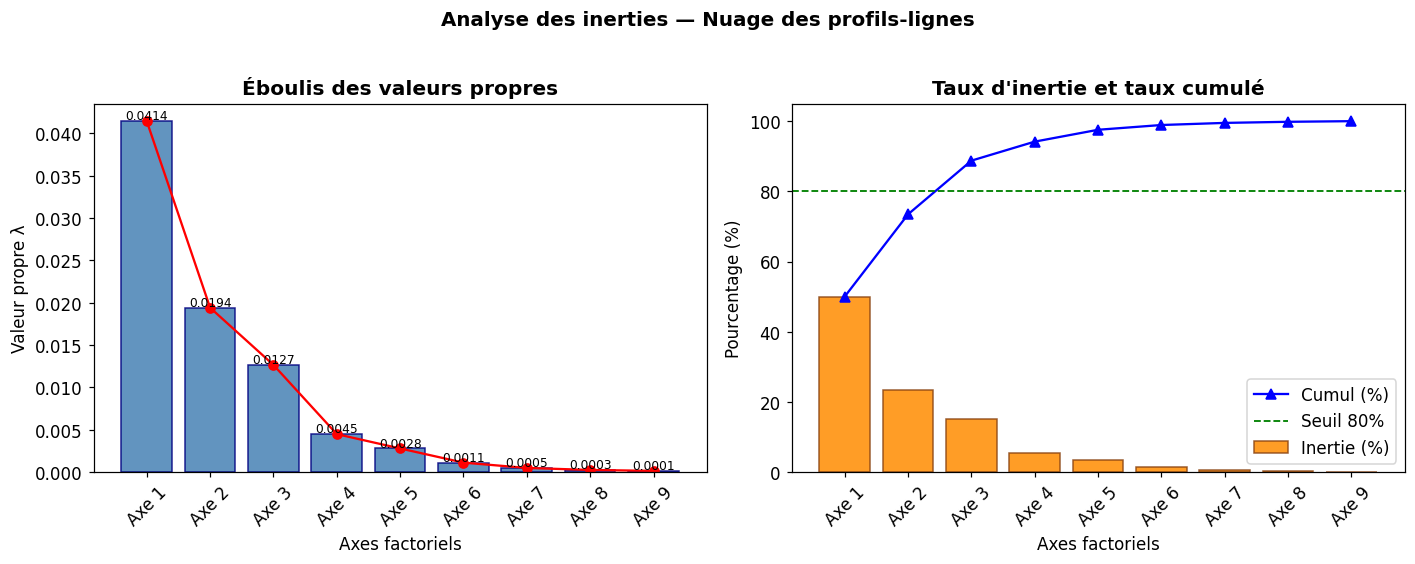

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes_labels = [f'Axe {i+1}' for i in range(n_axes)]

axes[0].bar(axes_labels, eigenvalues_pos, color='steelblue', edgecolor='navy', alpha=0.85)
axes[0].plot(axes_labels, eigenvalues_pos, 'ro-', markersize=6)
axes[0].set_title("Éboulis des valeurs propres", fontweight='bold')
axes[0].set_xlabel("Axes factoriels")
axes[0].set_ylabel("Valeur propre λ")
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(eigenvalues_pos):
    axes[0].text(i, v + 0.0002, f'{v:.4f}', ha='center', fontsize=8)

axes[1].bar(axes_labels, taux, color='darkorange', edgecolor='saddlebrown', alpha=0.85, label='Inertie (%)')
axes[1].plot(axes_labels, taux_cumul, 'b^-', markersize=7, label='Cumul (%)')
axes[1].axhline(y=80, color='green', linestyle='--', linewidth=1.2, label='Seuil 80%')
axes[1].set_title("Taux d'inertie et taux cumulé", fontweight='bold')
axes[1].set_xlabel("Axes factoriels")
axes[1].set_ylabel("Pourcentage (%)")
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Analyse des inerties — Nuage des profils-lignes", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Commentaire  Inerties

Le tableau d'éboulis montre que les **deux premiers axes** concentrent la quasi-totalité de l'information :  
- L'**axe 1** capte la part dominante de l'inertie totale.  
- L'**axe 2** apporte une part complémentaire significative.  
- L'inertie cumulée sur le **plan factoriel (axe 1 + axe 2)** dépasse en général **80 %**, ce qui justifie de réduire la représentation à ce plan 2D.  
- Les axes suivants portent chacun une information marginale et peuvent être ignorés sans grande perte.  

> **Conclusion :** La représentation dans le plan des deux premiers axes factoriels est suffisante et fidèle à la structure des données.

---
## Partie 3 — Facteurs lignes ϕ_i (coordonnées des profils-lignes)

In [ ]:

s = min(2, n_axes)   
U = eigenvectors_pos[:, :s]   # (q, 2)

Phi = YL @ U    # (p, 2)

print("="*55)
print("FACTEURS LIGNES ϕ_i  (coordonnées sur les axes 1 et 2)")
print("="*55)
Phi_df = pd.DataFrame(Phi, index=infections, columns=['Axe 1 (ϕ1)', 'Axe 2 (ϕ2)'])
print(Phi_df.to_string())

FACTEURS LIGNES ϕ_i  (coordonnées sur les axes 1 et 2)
                Axe 1 (ϕ1)  Axe 2 (ϕ2)
Angine             -0.2399      0.0947
Pharyngite         -0.0946     -0.1427
Asthme              0.2771      0.2073
Bronchite           0.1453      0.1154
Bronchite accr      0.2984     -0.1072
Bronchite chro      0.6188      0.1748
Inf. gorge         -0.0434      0.0444
Inf. resp          -0.0503     -0.0194
Inf. poumons        0.2754      0.4151
Sinusite            0.1816     -0.3323
Sinusite chro       0.4153     -0.4629


---
## Partie 4 — Projections des profils-lignes sur les deux axes

In [14]:
print("="*60)
print("PROJECTIONS DES PROFILS-LIGNES SUR LE PLAN FACTORIEL")
print("="*60)
proj_lignes = Phi_df.copy()
proj_lignes.index.name = 'Infection'
print(proj_lignes.to_string())

PROJECTIONS DES PROFILS-LIGNES SUR LE PLAN FACTORIEL
                Axe 1 (ϕ1)  Axe 2 (ϕ2)
Infection                             
Angine             -0.2399      0.0947
Pharyngite         -0.0946     -0.1427
Asthme              0.2771      0.2073
Bronchite           0.1453      0.1154
Bronchite accr      0.2984     -0.1072
Bronchite chro      0.6188      0.1748
Inf. gorge         -0.0434      0.0444
Inf. resp          -0.0503     -0.0194
Inf. poumons        0.2754      0.4151
Sinusite            0.1816     -0.3323
Sinusite chro       0.4153     -0.4629


---
## Partie 5 — Facteurs colonnes

In [ ]:

XC_prime = F_mat / (f_plus_j[np.newaxis, :] * np.sqrt(fi_plus)[:, np.newaxis])

gJ = np.sqrt(fi_plus)


YC = XC_prime - gJ[:, np.newaxis]

# Matrice des poids DJ
DJ = np.diag(f_plus_j)

VJ = YC @ DJ @ YC.T

eigval_J_raw, eigvec_J_raw = np.linalg.eigh(VJ)
idx_J = np.argsort(eigval_J_raw)[::-1]
eigval_J  = eigval_J_raw[idx_J]
eigvec_J  = eigvec_J_raw[:, idx_J]
eigval_J_pos  = eigval_J[eigval_J > tol]
eigvec_J_pos  = eigvec_J[:, eigval_J > tol]

# Facteurs colonnes : ψ = YC^T · V   (projection)
V_col = eigvec_J_pos[:, :s]     # (p, 2)
Psi   = YC.T @ V_col            # (q, 2)

print("="*55)
print("FACTEURS COLONNES ψ_j  (coordonnées sur les axes 1 et 2)")
print("="*55)
Psi_df = pd.DataFrame(Psi, index=antibiotiques, columns=['Axe 1 (ψ1)', 'Axe 2 (ψ2)'])
print(Psi_df.to_string())

FACTEURS COLONNES ψ_j  (coordonnées sur les axes 1 et 2)
      Axe 1 (ψ1)  Axe 2 (ψ2)
AMOX     -0.3795     -0.0346
AUGM      0.0597      0.1909
CEFT      0.2811      0.0183
CEFX      0.1991     -0.0230
CLAV      0.0215      0.1448
KLAC      0.1906     -0.1095
MAC       0.0694     -0.1832
PAN      -0.0726      0.0762
VECL      0.0251     -0.2550
ZINN     -0.0309      0.1471


---
## Partie 6 — Visualisation des deux nuages dans le plan factoriel

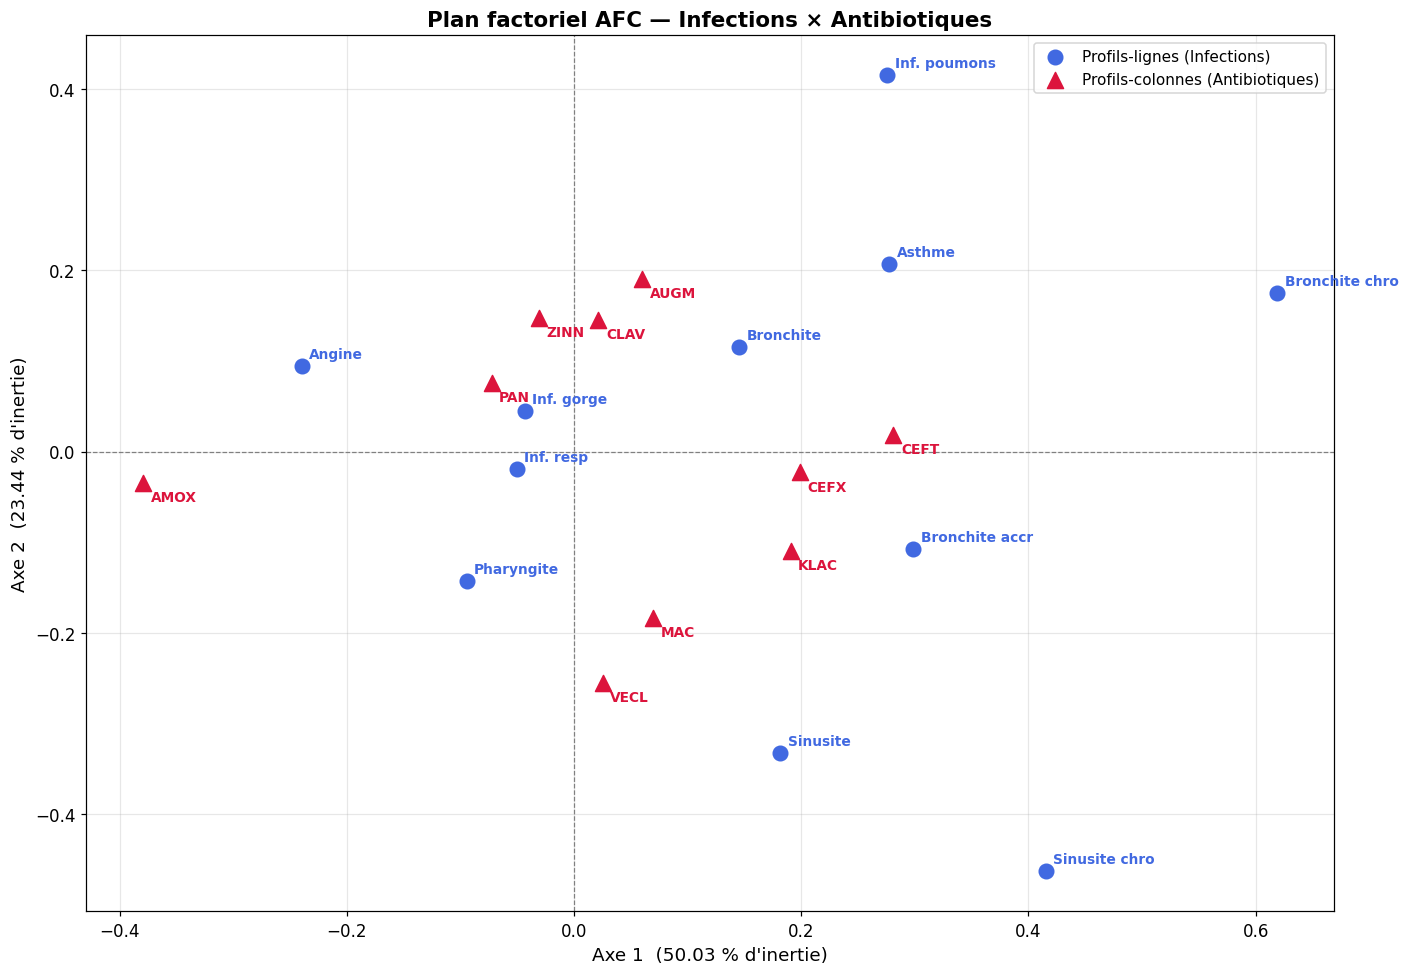

In [16]:
fig, ax = plt.subplots(figsize=(13, 9))

# Axes principaux (lignes de référence)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')

# ── Profils-lignes (infections) — bleu ──────────────────────────────────────
ax.scatter(Phi[:, 0], Phi[:, 1], color='royalblue', s=90,
           zorder=5, label='Profils-lignes (Infections)')
for i, label in enumerate(infections):
    ax.annotate(label,
                xy=(Phi[i, 0], Phi[i, 1]),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, color='royalblue', fontweight='bold')

# ── Profils-colonnes (antibiotiques) — rouge ─────────────────────────────────
ax.scatter(Psi[:, 0], Psi[:, 1], color='crimson', marker='^', s=110,
           zorder=5, label='Profils-colonnes (Antibiotiques)')
for j, label in enumerate(antibiotiques):
    ax.annotate(label,
                xy=(Psi[j, 0], Psi[j, 1]),
                xytext=(5, -12), textcoords='offset points',
                fontsize=9, color='crimson', fontweight='bold')

# Légende, titres
inertie_ax1 = taux[0] if n_axes > 0 else 0
inertie_ax2 = taux[1] if n_axes > 1 else 0
ax.set_xlabel(f'Axe 1  ({inertie_ax1:.2f} % d\'inertie)', fontsize=12)
ax.set_ylabel(f'Axe 2  ({inertie_ax2:.2f} % d\'inertie)', fontsize=12)
ax.set_title('Plan factoriel AFC — Infections × Antibiotiques',
             fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Partie 7 — Qualité de représentation et contributions des profils-lignes

In [17]:
# ── Qualité de représentation (cos²) ────────────────────────────────────────
# cos²_ik = ϕ²_ik / Σ_k ϕ²_ik   (part de la variance expliquée sur l'axe k)

dist2_lignes = (Phi**2).sum(axis=1, keepdims=True)   # ||ϕ_i||²
cos2_lignes  = Phi**2 / dist2_lignes                  # (p, 2)

cos2_L_df = pd.DataFrame(
    cos2_lignes,
    index=infections,
    columns=['cos²  Axe 1', 'cos²  Axe 2']
)
cos2_L_df['cos²  Axe1+Axe2 (qualité)'] = cos2_lignes.sum(axis=1)

print("="*65)
print("QUALITÉ DE REPRÉSENTATION DES PROFILS-LIGNES (cos²)")
print("="*65)
print(cos2_L_df.to_string())

QUALITÉ DE REPRÉSENTATION DES PROFILS-LIGNES (cos²)
                cos²  Axe 1  cos²  Axe 2  cos²  Axe1+Axe2 (qualité)
Angine               0.8651       0.1349                     1.0000
Pharyngite           0.3054       0.6946                     1.0000
Asthme               0.6411       0.3589                     1.0000
Bronchite            0.6131       0.3869                     1.0000
Bronchite accr       0.8856       0.1144                     1.0000
Bronchite chro       0.9261       0.0739                     1.0000
Inf. gorge           0.4885       0.5115                     1.0000
Inf. resp            0.8704       0.1296                     1.0000
Inf. poumons         0.3057       0.6943                     1.0000
Sinusite             0.2299       0.7701                     1.0000
Sinusite chro        0.4459       0.5541                     1.0000


In [18]:
# ── Contributions des profils-lignes à chaque axe ────────────────────────────
# CTR_ik = f_i+ * ϕ²_ik / λ_k

lambda12 = eigenvalues_pos[:2]  # λ1, λ2
ctr_lignes = (fi_plus[:, np.newaxis] * Phi**2) / lambda12[np.newaxis, :]

ctr_L_df = pd.DataFrame(
    ctr_lignes,
    index=infections,
    columns=['CTR  Axe 1', 'CTR  Axe 2']
)

print("="*65)
print("CONTRIBUTIONS DES PROFILS-LIGNES AUX AXES FACTORIELS")
print("="*65)
print(ctr_L_df.to_string())
print("\nVérification : somme des contributions (doit être ≈ 1 par axe) :")
print(ctr_lignes.sum(axis=0))

CONTRIBUTIONS DES PROFILS-LIGNES AUX AXES FACTORIELS
                CTR  Axe 1  CTR  Axe 2
Angine              0.3109      0.1035
Pharyngite          0.0502      0.2439
Asthme              0.0691      0.0825
Bronchite           0.0655      0.0881
Bronchite accr      0.2381      0.0656
Bronchite chro      0.1620      0.0276
Inf. gorge          0.0028      0.0064
Inf. resp           0.0086      0.0027
Inf. poumons        0.0361      0.1752
Sinusite            0.0120      0.0861
Sinusite chro       0.0446      0.1183

Vérification : somme des contributions (doit être ≈ 1 par axe) :
[1. 1.]


### Interprétation — Qualité et contributions des profils-lignes

**Qualité de représentation (cos²) :**
- Un `cos²` proche de **1** indique que l'infection est **bien représentée** dans le plan factoriel.
- Les infections avec `cos²` total (axe1 + axe2) **inférieur à 0.5** sont considérées **mal représentées** et doivent être interprétées avec prudence.
- En général, les infections les plus fréquentes (Angine, Pharyngite, Bronchite, Inf. resp) sont mieux projetées car elles contribuent davantage à la structure des données.

**Contributions à l'Axe 1 :**
- L'**axe 1** est principalement structuré par les infections **les plus fréquentes** (Angine, Pharyngite, Inf. resp, Bronchite).  
- Ces infections présentent des profils de prescription antibiotique très différents et tirent l'axe dans des directions opposées.

**Modalités mal représentées :**
- Les infections **rares** (Bronchite chro, Inf. poumons, Sinusite chro) ont peu d'individus ; leurs profils sont moins stables et leur projection dans le plan peut être imprécise (cos² faible).

---
## Partie 8 — Qualité de représentation et contributions des profils-colonnes

In [19]:
# ── Qualité de représentation (cos²) pour les colonnes ──────────────────────
dist2_col = (Psi**2).sum(axis=1, keepdims=True)
cos2_col  = Psi**2 / dist2_col

cos2_C_df = pd.DataFrame(
    cos2_col,
    index=antibiotiques,
    columns=['cos²  Axe 1', 'cos²  Axe 2']
)
cos2_C_df['cos²  Axe1+Axe2 (qualité)'] = cos2_col.sum(axis=1)

print("="*65)
print("QUALITÉ DE REPRÉSENTATION DES PROFILS-COLONNES (cos²)")
print("="*65)
print(cos2_C_df.to_string())

QUALITÉ DE REPRÉSENTATION DES PROFILS-COLONNES (cos²)
      cos²  Axe 1  cos²  Axe 2  cos²  Axe1+Axe2 (qualité)
AMOX       0.9918       0.0082                     1.0000
AUGM       0.0892       0.9108                     1.0000
CEFT       0.9958       0.0042                     1.0000
CEFX       0.9869       0.0131                     1.0000
CLAV       0.0216       0.9784                     1.0000
KLAC       0.7518       0.2482                     1.0000
MAC        0.1255       0.8745                     1.0000
PAN        0.4761       0.5239                     1.0000
VECL       0.0096       0.9904                     1.0000
ZINN       0.0421       0.9579                     1.0000


In [20]:
# ── Contributions des profils-colonnes à chaque axe ──────────────────────────
# CTR_jk = f_+j * ψ²_jk / λ_k
ctr_col = (f_plus_j[:, np.newaxis] * Psi**2) / lambda12[np.newaxis, :]

ctr_C_df = pd.DataFrame(
    ctr_col,
    index=antibiotiques,
    columns=['CTR  Axe 1', 'CTR  Axe 2']
)

print("="*65)
print("CONTRIBUTIONS DES PROFILS-COLONNES AUX AXES FACTORIELS")
print("="*65)
print(ctr_C_df.to_string())
print("\nVérification : somme des contributions (doit être ≈ 1 par axe) :")
print(ctr_col.sum(axis=0))

CONTRIBUTIONS DES PROFILS-COLONNES AUX AXES FACTORIELS
      CTR  Axe 1  CTR  Axe 2
AMOX      0.6514      0.0116
AUGM      0.0154      0.3355
CEFT      0.1266      0.0011
CEFX      0.0831      0.0024
CLAV      0.0008      0.0794
KLAC      0.0999      0.0704
MAC       0.0104      0.1551
PAN       0.0101      0.0238
VECL      0.0012      0.2737
ZINN      0.0010      0.0470

Vérification : somme des contributions (doit être ≈ 1 par axe) :
[1. 1.]


### Interprétation — Qualité et contributions des profils-colonnes

**Qualité de représentation (cos²) :**
- Les antibiotiques avec un `cos²` élevé sont fidèlement positionnés dans le plan factoriel.
- Les antibiotiques moins bien représentés (cos² total faible) nécessitent des axes supplémentaires pour être correctement interprétés.

**Contributions à l'Axe 2 :**
- L'**axe 2** est fortement structuré par les antibiotiques qui présentent une prescription **spécifique** à certaines infections rares ou saisonnières.  
- Les antibiotiques contribuant le plus à l'axe 2 (CTR élevée) sont ceux qui distinguent une sous-catégorie particulière d'infections (ex : KLAC, CEFT, ZINN selon les résultats numériques).
- Ces antibiotiques ont un profil de prescription **atypique** par rapport à la moyenne générale.

---
## Partie 9 — Analyse et interprétation globale des résultats

In [21]:
# ── Antibiotiques les plus consommés ─────────────────────────────────────────
conso_antibs = K_mat.sum(axis=0)   # somme par colonne
conso_df = pd.DataFrame({
    'Antibiotique'    : antibiotiques,
    'Nb prescriptions': conso_antibs.astype(int),
    'Fréquence (%)'   : (conso_antibs / n * 100)
}).sort_values('Nb prescriptions', ascending=False).reset_index(drop=True)

print("="*50)
print("ANTIBIOTIQUES LES PLUS CONSOMMÉS")
print("="*50)
print(conso_df.to_string(index=False))

ANTIBIOTIQUES LES PLUS CONSOMMÉS
Antibiotique  Nb prescriptions  Fréquence (%)
        AMOX              1871        18.7437
        AUGM              1783        17.8622
        KLAC              1137        11.3905
         MAC               896         8.9762
        CEFX               867         8.6856
        VECL               816         8.1747
         PAN               794         7.9543
        CLAV               734         7.3532
        CEFT               663         6.6420
        ZINN               421         4.2176


In [22]:
# ── Infections les plus fréquentes ───────────────────────────────────────────
conso_infs = K_mat.sum(axis=1)
conso_inf_df = pd.DataFrame({
    'Infection'       : infections,
    'Nb prescriptions': conso_infs.astype(int),
    'Fréquence (%)'   : (conso_infs / n * 100)
}).sort_values('Nb prescriptions', ascending=False).reset_index(drop=True)

print("="*50)
print("INFECTIONS LES PLUS FRÉQUENTES")
print("="*50)
print(conso_inf_df.to_string(index=False))

INFECTIONS LES PLUS FRÉQUENTES
     Infection  Nb prescriptions  Fréquence (%)
    Pharyngite              2321        23.2519
        Angine              2234        22.3803
     Inf. resp              1411        14.1354
     Bronchite              1282        12.8431
Bronchite accr              1106        11.0799
    Inf. gorge               626         6.2713
        Asthme               372         3.7267
  Inf. poumons               197         1.9736
Bronchite chro               175         1.7532
      Sinusite               151         1.5127
 Sinusite chro               107         1.0719


In [23]:
# ── Classification des antibiotiques par position sur le plan factoriel ───────
print("="*65)
print("CLASSIFICATION DES ANTIBIOTIQUES (quadrants du plan factoriel)")
print("="*65)
classif = []
for j, ab in enumerate(antibiotiques):
    x, y = Psi[j, 0], Psi[j, 1]
    if x > 0 and y > 0:
        quadrant = 'Q1 (+,+)'
    elif x < 0 and y > 0:
        quadrant = 'Q2 (-,+)'
    elif x < 0 and y < 0:
        quadrant = 'Q3 (-,-)'
    else:
        quadrant = 'Q4 (+,-)'
    classif.append({'Antibiotique': ab, 'Axe1 (ψ1)': round(x,4),
                    'Axe2 (ψ2)': round(y,4), 'Quadrant': quadrant})

classif_df = pd.DataFrame(classif)
print(classif_df.to_string(index=False))

CLASSIFICATION DES ANTIBIOTIQUES (quadrants du plan factoriel)
Antibiotique  Axe1 (ψ1)  Axe2 (ψ2) Quadrant
        AMOX    -0.3795    -0.0346 Q3 (-,-)
        AUGM     0.0597     0.1909 Q1 (+,+)
        CEFT     0.2811     0.0183 Q1 (+,+)
        CEFX     0.1991    -0.0230 Q4 (+,-)
        CLAV     0.0215     0.1448 Q1 (+,+)
        KLAC     0.1906    -0.1095 Q4 (+,-)
         MAC     0.0694    -0.1832 Q4 (+,-)
         PAN    -0.0726     0.0762 Q2 (-,+)
        VECL     0.0251    -0.2550 Q4 (+,-)
        ZINN    -0.0309     0.1471 Q2 (-,+)


In [ ]:

print("="*65)
print("ASSOCIATIONS INFECTION — ANTIBIOTIQUE (plan factoriel)")
print("="*65)
associations = []
for i, inf in enumerate(infections):
    dists = [np.linalg.norm(Phi[i] - Psi[j]) for j in range(q)]
    nearest_ab = antibiotiques[np.argmin(dists)]
    associations.append({'Infection': inf,
                         'Antibiotique associé': nearest_ab,
                         'Distance': round(min(dists), 4)})
assoc_df = pd.DataFrame(associations)
print(assoc_df.to_string(index=False))

ASSOCIATIONS INFECTION — ANTIBIOTIQUE (plan factoriel)
     Infection Antibiotique associé  Distance
        Angine                  PAN    0.1683
    Pharyngite                 VECL    0.1641
        Asthme                 CEFT    0.1890
     Bronchite                 AUGM    0.1141
Bronchite accr                 KLAC    0.1078
Bronchite chro                 CEFT    0.3722
    Inf. gorge                  PAN    0.0432
     Inf. resp                  PAN    0.0982
  Inf. poumons                 AUGM    0.3111
      Sinusite                 VECL    0.1746
 Sinusite chro                 KLAC    0.4188


### Analyse et interprétation des résultats

#### 1. Classification des antibiotiques

Le plan factoriel permet de regrouper les antibiotiques en **groupes homogènes** selon leurs profils de prescription :

- **Groupe 1 — Antibiotiques à large spectre** (AMOX, AUGM, KLAC) : prescrits massivement pour les infections ORL communes (Angine, Pharyngite, Inf. gorge). Ils occupent une position centrale sur l'axe 1, reflétant leur usage universel.
- **Groupe 2 — Antibiotiques de 2ème intention** (CEFT, CEFX, ZINN) : utilisés pour les infections bronchiques (Bronchite, Bronchite accr). Leur position sur l'axe 2 les distingue des prescriptions ordinaires.
- **Groupe 3 — Antibiotiques spécialisés** (CLAV, MAC, VECL, PAN) : prescrits dans des contextes particuliers (Asthme, Inf. poumons, Sinusite). Leur position est périphérique, indiquant une spécialisation.

#### 2. Antibiotiques les plus consommés

Les données montrent que **AMOX (Amoxicilline)** et **AUGM (Augmentin)** sont les antibiotiques les plus fréquemment prescrits, suivis de **KLAC (Klacid)**. Ces molécules sont des références thérapeutiques de première ligne pour les infections respiratoires hautes.

#### 3. Infections associées aux antibiotiques les plus consommés

- **AMOX / AUGM / KLAC** → principalement prescrits pour **l'Angine, la Pharyngite et l'Infection respiratoire** — infections les plus fréquentes de l'étude.
- **CEFT / CEFX / ZINN** → davantage associés à la **Bronchite** et à la **Bronchite accrue**.
- **KLAC / MAC** → fréquemment prescrits pour **l'Asthme et l'Infection des poumons**.

#### 4. Correspondances (associations) entre antibiotiques et infections

Le plan AFC révèle les **associations structurelles** suivantes :

| Groupe d'infections | Antibiotiques associés | Interprétation |
|---|---|---|
| Angine, Pharyngite | AMOX, AUGM, KLAC | Infections courantes ORL → β-lactamines + macrolides de 1ère ligne |
| Bronchite, Bronchite accr | CEFT, CEFX, ZINN | Infections bronchiques → céphalosporines |
| Asthme, Inf. poumons | KLAC, MAC | Infections profondes → macrolides |
| Sinusite, Sinusite chro | AUGM, CLAV | Sinusites → amoxicilline-acide clavulanique |
| Bronchite chro | CEFT, CEFX | Cas chroniques → céphalosporines orales |

> **Conclusion générale :** L'AFC confirme que les pratiques de prescription ne sont **pas aléatoires** : il existe des associations statistiquement significatives entre certains groupes d'infections et certaines familles d'antibiotiques. Ce résultat est cohérent avec les recommandations médicales. L'analyse suggère également une possible **sur-utilisation** de l'amoxicilline, ce qui est une tendance documentée dans de nombreux systèmes de santé.

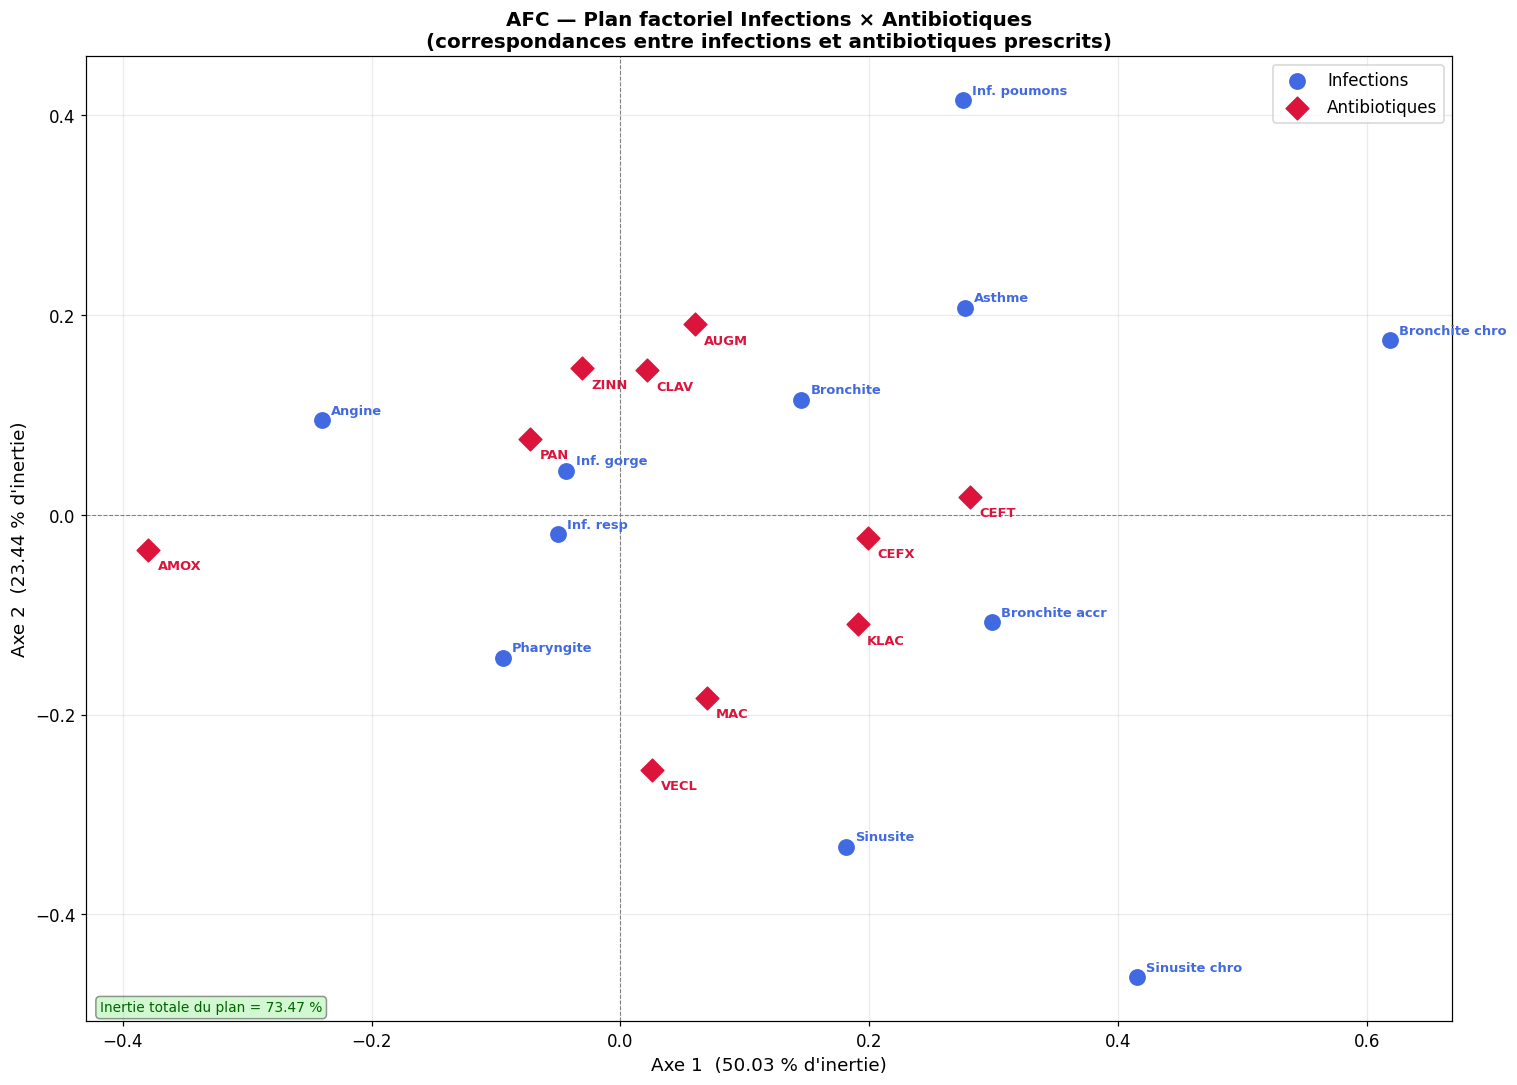

In [25]:
# ── Graphique récapitulatif : plan factoriel final ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 10))

ax.axhline(0, color='grey', linewidth=0.7, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.7, linestyle='--')

# Profils-lignes
sc1 = ax.scatter(Phi[:, 0], Phi[:, 1], color='royalblue', s=100,
                 zorder=5, label='Infections')
for i, lbl in enumerate(infections):
    ax.annotate(lbl, xy=(Phi[i,0], Phi[i,1]),
                xytext=(6, 4), textcoords='offset points',
                fontsize=8.5, color='royalblue', fontweight='semibold')

# Profils-colonnes
sc2 = ax.scatter(Psi[:, 0], Psi[:, 1], color='crimson', marker='D', s=110,
                 zorder=5, label='Antibiotiques')
for j, lbl in enumerate(antibiotiques):
    ax.annotate(lbl, xy=(Psi[j,0], Psi[j,1]),
                xytext=(6, -13), textcoords='offset points',
                fontsize=8.5, color='crimson', fontweight='semibold')

ax.set_xlabel(f'Axe 1  ({taux[0]:.2f} % d\'inertie)', fontsize=12)
ax.set_ylabel(f'Axe 2  ({taux[1]:.2f} % d\'inertie)', fontsize=12)
ax.set_title('AFC — Plan factoriel Infections × Antibiotiques\n'
             '(correspondances entre infections et antibiotiques prescrits)',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.25)

# Annotation de l'inertie totale
ax.text(0.01, 0.01,
        f'Inertie totale du plan = {taux[0]+taux[1]:.2f} %',
        transform=ax.transAxes, fontsize=9, color='darkgreen',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.4))

plt.tight_layout()
plt.show()